### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [8]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-120b")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hello". Simple greeting. Should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 72, 'total_tokens': 109, 'completion_time': 0.079256331, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.003560079, 'prompt_tokens_details': None, 'queue_time': 0.316417489, 'total_time': 0.08281641}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6fb4303df4', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02059-544a-79b3-9a27-5749788a1107-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 37, 'total_tokens': 109, 'output_token_details': {'reasoning': 19}})

### We Will start With Creating Nodes

In [15]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

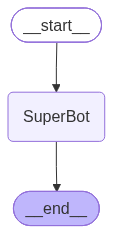

In [16]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [17]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is Chirag And I like whatever"})

{'messages': [HumanMessage(content='Hi,My name is Chirag And I like whatever', additional_kwargs={}, response_metadata={}, id='fe35d31f-0462-450d-8d6c-dab1b0228cba'),
  AIMessage(content='Hello Chirag! 👋 Nice to meet you. It sounds like you have a wide‑open curiosity—“like whatever” can lead to all kinds of interesting conversations. How can I assist you today? Whether you’re looking for information, a fun chat, or help with a specific topic, just let me know!', additional_kwargs={'reasoning_content': 'The user says "Hi,My name is Chirag And I like whatever". Probably they are greeting. We should respond politely, ask how we can help. Possibly ask about preferences. Should be friendly.'}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 82, 'total_tokens': 198, 'completion_time': 0.252881473, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.003337686, 'prompt_tokens_details': None, 'queue_time': 0.375070567, 'total_time': 0.256219159}